# True parameters at 1 PA model
```python
m1 = 1e6
m2 = 1e1
a = 0.8
e0 = 0.4
xI0 = 1.0
dist = 0.5 
qS = np.pi/4
phiS = 1.0
qK = 1 
phiK = np.pi/3

Phi_phi0 = 0.9
Phi_theta0 =0.5
Phi_r0 = 0.4

dt = 10.0
T = 1.0

chi2 = 0.9

dev_C_p=0.0
dev_C_e=0.0


evolve_1PA = False
evolve_primary = False
evolve_2PA = False
deviation_included=True
p0=7.5
best_fit = [13.81555957,10.00042571,0.80004275,7.49978425,0.39998768,0.78295617,1.00614064,0.96784745,0.35215207]
```

In [1]:
import numpy as np
import cupy as cp
import matplotlib.pyplot as plt

from itertools import product
import os
import h5py
from tqdm import tqdm
import pandas as pd

#few utils
from few.utils.utility import get_p_at_t
from few.utils.constants import MTSUN_SI
from few.utils.geodesic import get_fundamental_frequencies
#few trajectory
from few.trajectory.inspiral import EMRIInspiral
from few.trajectory.ode.flux import SuperKludgeFlux
#few waveform
from few.waveform import FastKerrEccentricEquatorialFlux, GenerateEMRIWaveform
from few.waveform.waveform import SuperKludgeWaveform
from few.utils.constants import YRSID_SI

#sef imports
from stableemrifisher.fisher import StableEMRIFisher
from stableemrifisher.utils import generate_PSD, padding, inner_product
from stableemrifisher.fisher.derivatives import derivative
from stableemrifisher.fisher.stablederivative import StableEMRIDerivative
from stableemrifisher.noise import sensitivity_LWA

#lisa-on-gpu import
from fastlisaresponse import ResponseWrapper  # Response function 

#LISAanalysistools imports
from lisatools.detector import ESAOrbits, EqualArmlengthOrbits #ESAOrbits correspond to esa-trailing-orbits.h5, EqualArmlengthOrbits are equalarmlength-orbits.h5
from lisatools.sensitivity import get_sensitivity, A1TDISens, E1TDISens, T1TDISens
from lisatools.sensitivity import get_sensitivity,CornishLISASens

use_gpu = True
from parismc.sampler import SamplerConfig
from parismc.sampler import Sampler

from smt.sampling_methods import LHS

if not use_gpu:
    
    import few
    
    #tune few configuration
    cfg_set = few.get_config_setter(reset=True)
    cfg_set.enable_backends("cpu")
    cfg_set.set_log_level("info");

else:
    pass #let the backend decide for itself



if(use_gpu):
    xp=cp
else:
    xp=np

startup


In [2]:
#waveform class setup
waveform_class = SuperKludgeWaveform
max_step_days = 10.0 #max trajectory step size in days
inspiral_kwargs = {
    "err":1e-11, #default = 1e-11
    "max_step_size":max_step_days*24*60*60, #in seconds
}
sum_kwargs = {
    "pad_output": True, # True if expecting waveforms smaller than LISA observation window.
}

waveform_class_kwargs = dict(inspiral_kwargs=inspiral_kwargs,
                              mode_selector_kwargs=dict(mode_selection_threshold=1e-5),
                              sum_kwargs=sum_kwargs,
                              use_gpu=use_gpu)

waveform_generator = GenerateEMRIWaveform
waveform_generator_kwargs = dict(return_list=False)

In [3]:
if(use_gpu):
    xp=cp
else:
    xp=np
best_fit = [13.81555957,10.00042571,0.80004275,7.49978425,0.39998768,0.78295617,1.00614064,0.96784745,0.35215207]
logm1 = best_fit[0]
m1= np.exp(logm1)
m2 = best_fit[1]
a = best_fit[2]
p0= best_fit[3]
e0 = best_fit[4]
xI0 = 1.0
dist = 0.5
qS = best_fit[5]
phiS = best_fit[6]
qK = 1 
phiK = np.pi/3
Phi_phi0 = best_fit[7]
Phi_theta0 =0.5
Phi_r0 = best_fit[8]

dt = 10.0
T = 1.0

chi2 = 0.9

dev_C_p=0.0
dev_C_e=0.0

evolve_1PA = False
evolve_primary = False
evolve_2PA = False
deviation_included=True


print(use_gpu)

pars_list_snr = [m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0,\
              chi2,evolve_1PA,evolve_primary,evolve_2PA,deviation_included,dev_C_p,dev_C_e,]

pars_list = [m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]

pars_list_com = [m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0,\
             chi2,evolve_1PA,evolve_primary,evolve_2PA,deviation_included,dev_C_p,dev_C_e]

add_param_args={"chi2":chi2,"evolve_1PA":evolve_1PA,"evolve_primary":evolve_primary,"evolve_2PA":evolve_2PA,"deviation_included":deviation_included,"devCp":dev_C_p,
"devCe":dev_C_e}

emri_kwargs = {"T":T, "dt":dt}

True


In [4]:
der_order = 8
Ndelta=16
sef = StableEMRIFisher(waveform_class=waveform_class, 
                       waveform_class_kwargs=waveform_class_kwargs,
                       waveform_generator=waveform_generator,
                       waveform_generator_kwargs=waveform_generator_kwargs,
                       stats_for_nerds = True, use_gpu = use_gpu,
                       deriv_type='stable',
                       noise_model=get_sensitivity,
                       noise_kwargs={'sens_fn':CornishLISASens,'return_type':'PSD'},
                       channels=["A","E"],
                       T = T, dt = dt,
                       stability_plot = False,
                       der_order = der_order, Ndelta = Ndelta,
                       plunge_check=True, return_derivatives=False
                       )
                   

SNR = sef.SNRcalc_SEF(*pars_list_com,**emri_kwargs,use_gpu=use_gpu)
print("SNR: ", SNR)

waveform shape: (2, 3155815)
wave ndim: 2
Computing SNR for parameters: (np.float64(1000049.0132368349), 10.00042571, 0.80004275, 7.49978425, 0.39998768, 1.0, 0.5, 0.78295617, 1.00614064, 1, 1.0471975511965976, 0.96784745, 0.5, 0.35215207, 0.9, False, False, False, True, 0.0, 0.0)
SNR:  109.40919820003411


Body is not plunging, Fisher should be stable.
waveform shape: (2, 3155815)
wave ndim: 2
Computing SNR for parameters: (np.float64(1000049.0132368349), 10.00042571, 0.80004275, 7.49978425, 0.39998768, 1.0, 0.5, 0.78295617, 1.00614064, 1, 1.0471975511965976, 0.96784745, 0.5, 0.35215207, 0.9, False, False, False, True, 0.0, 0.0)
Waveform Generated. SNR: 109.40919820003411
calculating stable deltas...
Gamma_ii for m1: 14229.541923632272
Gamma_ii for m1: 14229.541923332941
Gamma_ii for m1: 14229.5419233711
Gamma_ii for m1: 14229.541923028184
Gamma_ii for m1: 14229.541923647463
Gamma_ii for m1: 14229.541922269305
Gamma_ii for m1: 14229.54192141573
Gamma_ii for m1: 14229.541930573178
Gamma_ii for m1: 14229.54192786845
Gamma_ii for m1: 14229.541912806648
Gamma_ii for m1: 14229.541983394487
Gamma_ii for m1: 14229.541873927505
Gamma_ii for m1: 14229.54194594934
Gamma_ii for m1: 14229.542347114497
Gamma_ii for m1: 14229.541095484947
Gamma_ii for m1: 14229.545997909512
[np.float64(2.1035889902209

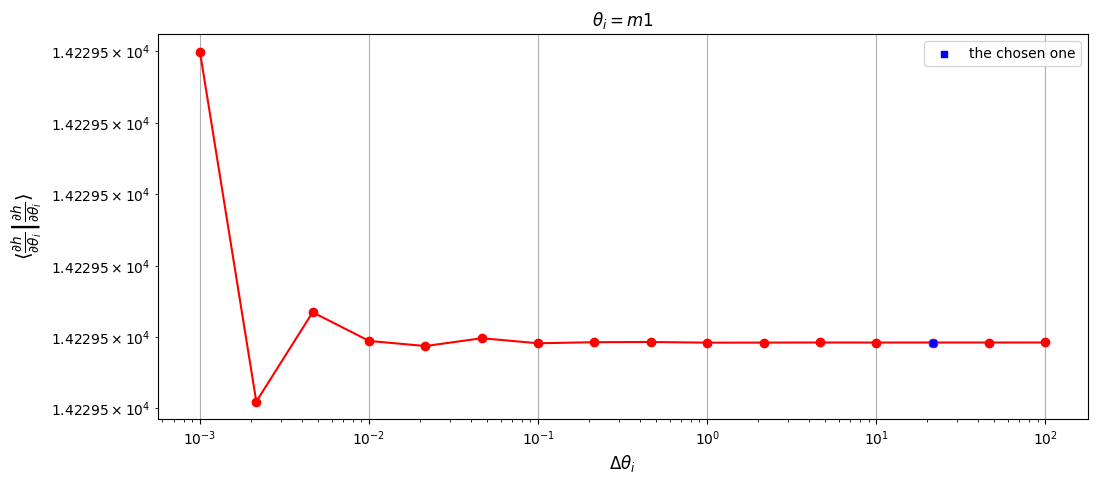

Gamma_ii for m2: 9073503160735.47
Gamma_ii for m2: 9073503160386.574
Gamma_ii for m2: 9073503160320.81
Gamma_ii for m2: 9073503160390.004
Gamma_ii for m2: 9073503161102.664
Gamma_ii for m2: 9073503163533.121
Gamma_ii for m2: 9073503158629.152
Gamma_ii for m2: 9073503144296.691
Gamma_ii for m2: 9073503177600.494
Gamma_ii for m2: 9073503267380.809
Gamma_ii for m2: 9073503160135.713
Gamma_ii for m2: 9073502984662.73
Gamma_ii for m2: 9073503056505.947
Gamma_ii for m2: 9073502150887.58
Gamma_ii for m2: 9073503354786.117
Gamma_ii for m2: 9073501119867.002
[np.float64(3.8452235945453215e-11), np.float64(7.2478810788968525e-12), np.float64(7.625870422028472e-12), np.float64(7.854299972089209e-11), np.float64(2.67863138133696e-10), np.float64(5.404713774013722e-10), np.float64(1.5795950813671033e-09), np.float64(3.670445921768251e-09), np.float64(9.894779536354465e-09), np.float64(1.1819590935318628e-08), np.float64(1.9339056009402688e-08), np.float64(7.917913990822042e-09), np.float64(9.980913

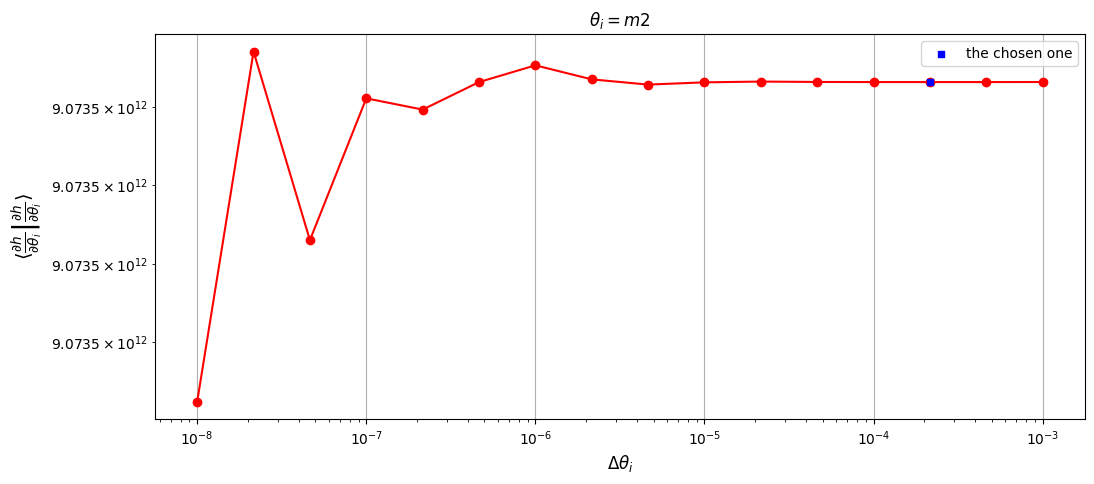

Gamma_ii for a: 1161295497224663.2
Gamma_ii for a: 1161295578270562.5
Gamma_ii for a: 1161295698729491.0
Gamma_ii for a: 1161295056862184.5
Gamma_ii for a: 1161295280691789.0
Gamma_ii for a: 1161294773741586.2
Gamma_ii for a: 1161292212467358.0
Gamma_ii for a: 1161290285754129.0
Gamma_ii for a: 1161332555324010.2
Gamma_ii for a: 1161315432910643.0
Gamma_ii for a: 1161414307868961.2
Gamma_ii for a: 1161501045277280.8
Gamma_ii for a: 1160659256504699.0
Gamma_ii for a: 1160349256390781.5
Gamma_ii for a: 1161483343885843.5
Gamma_ii for a: 1169438961102560.5
[np.float64(6.978920850684377e-08), np.float64(1.0372804155891338e-07), np.float64(5.52716816202011e-07), np.float64(1.9274133652438824e-07), np.float64(4.3653877913929857e-07), np.float64(2.205538107250498e-06), np.float64(1.659114222030036e-06), np.float64(3.6397472616667364e-05), np.float64(1.474398159364466e-05), np.float64(8.513323595924371e-05), np.float64(7.467699548974018e-05), np.float64(0.0007252677888571528), np.float64(0.000

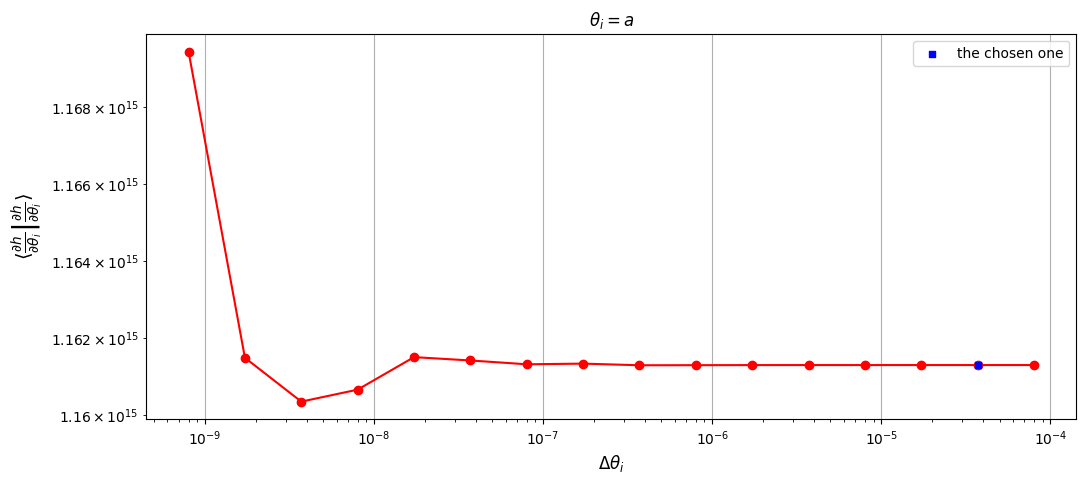

Gamma_ii for p0: 750159941109552.2
Gamma_ii for p0: 750159954803949.1
Gamma_ii for p0: 750159958783277.8
Gamma_ii for p0: 750159982889112.0
Gamma_ii for p0: 750159912028577.8
Gamma_ii for p0: 750160209827497.4
Gamma_ii for p0: 750159866799689.9
Gamma_ii for p0: 750159661549653.5
Gamma_ii for p0: 750158724644650.8
Gamma_ii for p0: 750160658216811.4
Gamma_ii for p0: 750159932860102.6
Gamma_ii for p0: 750149276350554.2
Gamma_ii for p0: 750212154190961.2
Gamma_ii for p0: 749987866427871.6
Gamma_ii for p0: 750174063779264.6
Gamma_ii for p0: 750237036766448.0
[np.float64(1.825530246889674e-08), np.float64(5.304640134957714e-09), np.float64(3.2134257758139176e-08), np.float64(9.446057182445192e-08), np.float64(3.969804259459192e-07), np.float64(4.572729396514042e-07), np.float64(2.7360846883049095e-07), np.float64(1.248942353091755e-06), np.float64(2.5775440759866657e-06), np.float64(9.669360851951445e-07), np.float64(1.4205851934189e-05), np.float64(8.381341205383202e-05), np.float64(0.00029

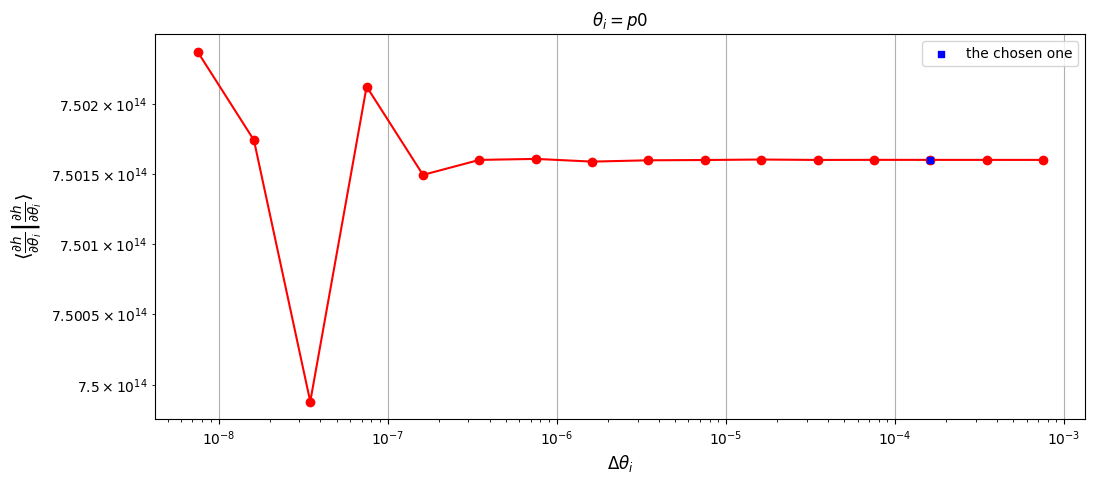

Gamma_ii for e0: 2441707799611295.0
Gamma_ii for e0: 2441707604211719.5
Gamma_ii for e0: 2441707281757416.0
Gamma_ii for e0: 2441707877182427.5
Gamma_ii for e0: 2441708999655059.0
Gamma_ii for e0: 2441702215030674.5
Gamma_ii for e0: 2441703181938516.0
Gamma_ii for e0: 2441743708574075.5
Gamma_ii for e0: 2441687066538553.0
Gamma_ii for e0: 2441679761290424.5
Gamma_ii for e0: 2441588200964405.0
Gamma_ii for e0: 2441274772118267.5
Gamma_ii for e0: 2441249859403875.5
Gamma_ii for e0: 2442791340320824.0
Gamma_ii for e0: 2437802801225679.0
Gamma_ii for e0: 2445967362882043.5
[np.float64(8.002578816683613e-08), np.float64(1.3206099924799907e-07), np.float64(2.438559571618706e-07), np.float64(4.59707783220102e-07), np.float64(2.7786453002889077e-06), np.float64(3.9599728937255713e-07), np.float64(1.659741578003969e-05), np.float64(2.3197909469536707e-05), np.float64(2.9918944508264205e-06), np.float64(3.750031474731673e-05), np.float64(0.0001283873694666255), np.float64(1.0204901516341876e-05)

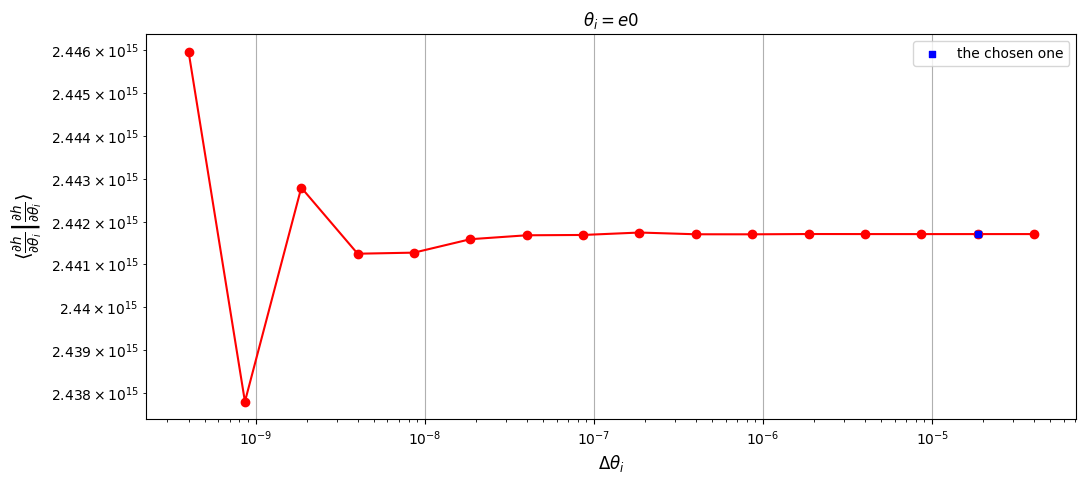

Gamma_ii for qS: 27950.47202025485
Gamma_ii for qS: 27950.472079631563
Gamma_ii for qS: 27950.47207976203
Gamma_ii for qS: 27950.472079762094
Gamma_ii for qS: 27950.472079761967
Gamma_ii for qS: 27950.472079761672
Gamma_ii for qS: 27950.472079764542
Gamma_ii for qS: 27950.472079757656
Gamma_ii for qS: 27950.472079751875
Gamma_ii for qS: 27950.472079737377
Gamma_ii for qS: 27950.47207967546
Gamma_ii for qS: 27950.472079832183
Gamma_ii for qS: 27950.4720794889
Gamma_ii for qS: 27950.472080075506
Gamma_ii for qS: 27950.472079261923
Gamma_ii for qS: 27950.47207920635
[np.float64(2.124354619844138e-09), np.float64(4.667727815387717e-12), np.float64(2.3428448128096235e-15), np.float64(4.555531580463178e-15), np.float64(1.0542801657643465e-14), np.float64(1.0269469762814617e-13), np.float64(2.4638917948051785e-13), np.float64(2.0682113375310295e-13), np.float64(5.186798099474781e-13), np.float64(2.215289928563522e-12), np.float64(5.607208585310305e-12), np.float64(1.2281843299093873e-11), np.

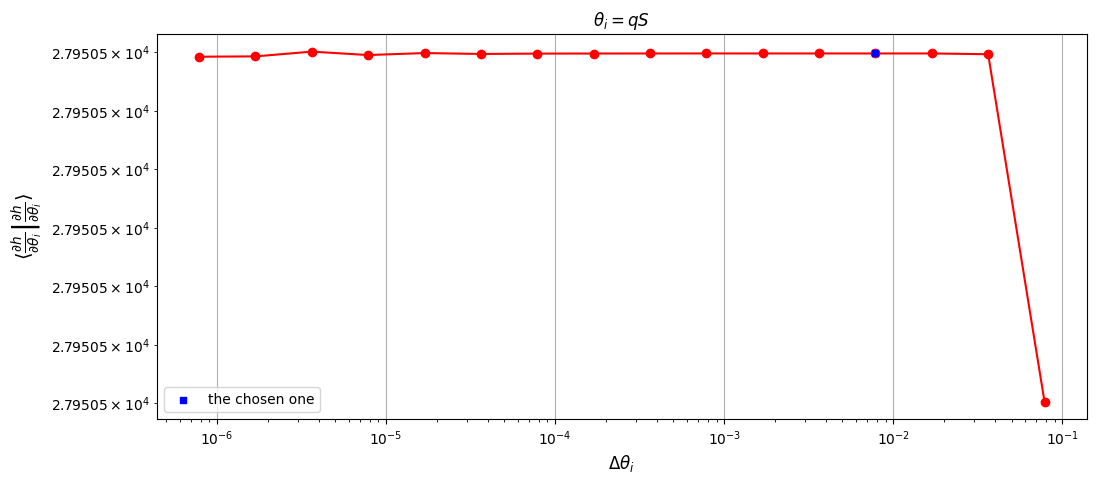

Gamma_ii for phiS: 703219.747677258
Gamma_ii for phiS: 703219.7476554406
Gamma_ii for phiS: 703219.7476553923
Gamma_ii for phiS: 703219.7476553922
Gamma_ii for phiS: 703219.7476553923
Gamma_ii for phiS: 703219.7476553922
Gamma_ii for phiS: 703219.7476553923
Gamma_ii for phiS: 703219.7476553924
Gamma_ii for phiS: 703219.7476553923
Gamma_ii for phiS: 703219.7476553923
Gamma_ii for phiS: 703219.7476553917
Gamma_ii for phiS: 703219.7476553917
Gamma_ii for phiS: 703219.747655394
Gamma_ii for phiS: 703219.7476554008
Gamma_ii for phiS: 703219.7476554041
Gamma_ii for phiS: 703219.7476553681
[np.float64(3.1025003971128256e-11), np.float64(6.870165224918153e-14), np.float64(1.655461499980278e-16), np.float64(1.6554614999802777e-16), np.float64(1.655461499980278e-16), np.float64(1.6554614999802777e-16), np.float64(1.6554614999802775e-16), np.float64(1.6554614999802777e-16), np.float64(0.0), np.float64(8.277307499901396e-16), np.float64(0.0), np.float64(3.3109229999605475e-15), np.float64(9.601676

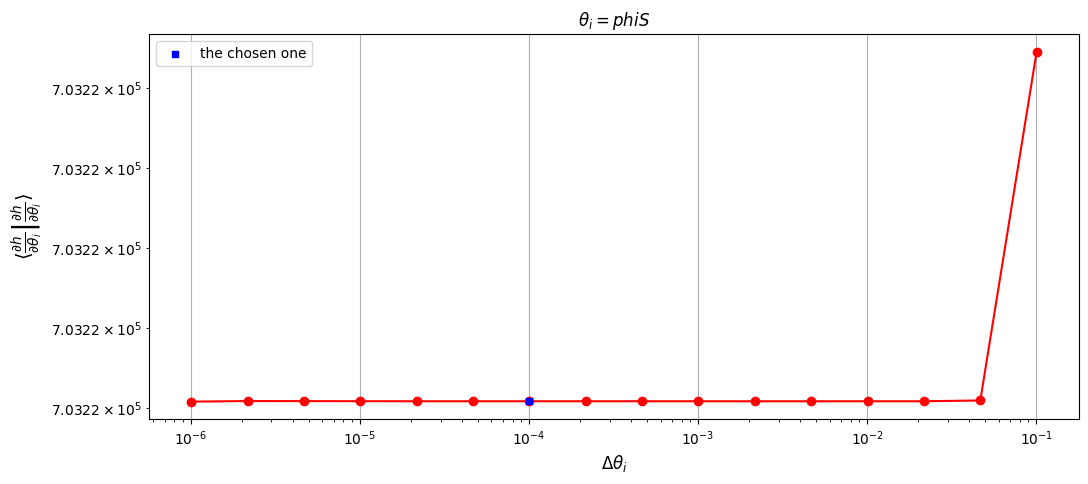

stable deltas: {'m1': 21.545402858495933, 'm2': 0.0002154526406471075, 'a': 3.713469494812866e-05, 'p0': 0.00016157795355954766, 'e0': 1.8565783490706828e-05, 'qS': 0.007829561699999998, 'phiS': 0.00010061406400000001, 'Phi_phi0': 0.0, 'Phi_r0': 0.0}
Time taken to compute stable deltas is 225.77207398414612 seconds
calculating Fisher matrix...
Finished derivatives
Calculated Fisher is *atleast* positive-definite.
Time taken to compute FM is 15.244399785995483 seconds


In [5]:
param_names = ['m1','m2','a','p0','e0','qS','phiS','Phi_phi0','Phi_r0']
pars_list = [m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]

param_dict = {
    'm1': m1,
    'm2': m2,
    'a': a,
    'p0': p0,
    'e0': e0,
    'xI0': xI0,
    'dist': dist,
    'qS': qS,
    'phiS': phiS,
    'qK': qK,
    'phiK': phiK,
    'Phi_phi0': Phi_phi0,
    'Phi_theta0': Phi_theta0,
    'Phi_r0': Phi_r0
}


Fisher = sef(wave_params = param_dict,param_names=param_names, add_param_args=add_param_args,
            live_dangerously = False, stability_plot = True,der_order = der_order, Ndelta = Ndelta,return_derivatives=True
            )


In [6]:
def logmasstransform(Fisher, m1, index_of_m1 = 0):    
    J = np.eye(len(Fisher))
    J[index_of_m1,index_of_m1] = m1
    
    return J.T@Fisher@J
fisher_=logmasstransform(Fisher[-1], m1, index_of_m1 = 0)
cov=np.linalg.inv(fisher_)
std= np.sqrt(np.diag(cov))
params_truth_in = np.array([np.log(1e6), 10, 0.8, 7.5, 0.4, np.pi/4, 1.0,  0.9,0.4])

In [7]:
from scipy.stats import chi2
def plot_confidence_ellipse(ax, mean, cov, i, j, levels=[0.90, 0.99]):

    # Extract 2x2 sub-covariance
    cov2 = cov[np.ix_([i, j], [i, j])]
    mean2 = mean[[i, j]]
    
    # Eigen decomposition
    eigvals, eigvecs = np.linalg.eigh(cov2)
    order = np.argsort(eigvals)[::-1]
    eigvals = eigvals[order]
    eigvecs = eigvecs[:, order]

    theta = np.linspace(0, 2*np.pi, 400)

    for p in levels:
        chi2_val = chi2.ppf(p, df=2)
        r1 = np.sqrt(eigvals[0] * chi2_val)
        r2 = np.sqrt(eigvals[1] * chi2_val)
        
        ellipse = np.vstack([r1*np.cos(theta), r2*np.sin(theta)])
        ellipse = eigvecs @ ellipse + mean2[:, None]

        ax.plot(ellipse[0], ellipse[1], label=f"{int(p*100)}%", lw=1)


# --------------------------------------------------------------------
# Main triangle plot function (WITH LEGEND)
# --------------------------------------------------------------------
def triangle_plot(best_fit, cov, param_truth=None, labels=None,levels=[0.90, 0.99]):
    D = len(best_fit)
    if labels is None:
        labels = [f"p{i}" for i in range(D)]

    fig, axes = plt.subplots(D, D, figsize=(2.2*D, 2.2*D))
    
    legend_ax = axes[-1, -1]  # bottom-right panel for legend only
    legend_handles = []       # store handles for legend

    for i in range(D):
        for j in range(D):

            ax = axes[i, j]

            if i < j:
                ax.axis("off")
                continue

            # ==========================
            # Diagonal panels
            # ==========================
            if i == j:
                ax.axis("off")
                continue
                sigma = np.sqrt(cov[i, i])
                x = np.linspace(best_fit[i] - 4*sigma,
                                best_fit[i] + 4*sigma, 300)
                y = np.exp(-0.5*((x - best_fit[i])/sigma)**2)

                ax.plot(x, y, lw=1.5)

                if param_truth is not None:
                    line_truth = ax.axvline(param_truth[i], color='red', linestyle='--', lw=1)

                ax.set_yticks([])
                ax.set_xlabel(labels[i])

            # ==========================
            # Off-diagonal panels
            # ==========================
            else:
                # Ellipses
                plot_confidence_ellipse(ax, best_fit, cov, j, i,levels=levels)

                # Best-fit point
                bestfit_handle = ax.scatter(best_fit[j], best_fit[i],
                                            color="black", s=12, label="Best-fit")

                # Truth point
                if param_truth is not None:
                    truth_handle = ax.scatter(param_truth[j], param_truth[i],
                                              color="red", marker="x", s=30,
                                              label="Param truth")

                ax.set_xlabel(labels[j])
                ax.set_ylabel(labels[i])

                # Collect handles only once (avoid duplicates)
                if i == D - 1 and j == 0:
                    # ellipse handles (match levels dynamically)
                    level_labels = {f"{int(p*100)}%" for p in levels}
                    for item in ax.get_lines():
                        if item.get_label() in level_labels:
                            legend_handles.append(item)
                
                    legend_handles.append(bestfit_handle)
                    if param_truth is not None:
                        legend_handles.append(truth_handle)

    # Add the legend to bottom-right subplot
    legend_ax.legend(handles=legend_handles, loc="upper right", fontsize=9)
    legend_ax.axis("off")  # hide this subplot except for legend

    plt.tight_layout()
    plt.show()


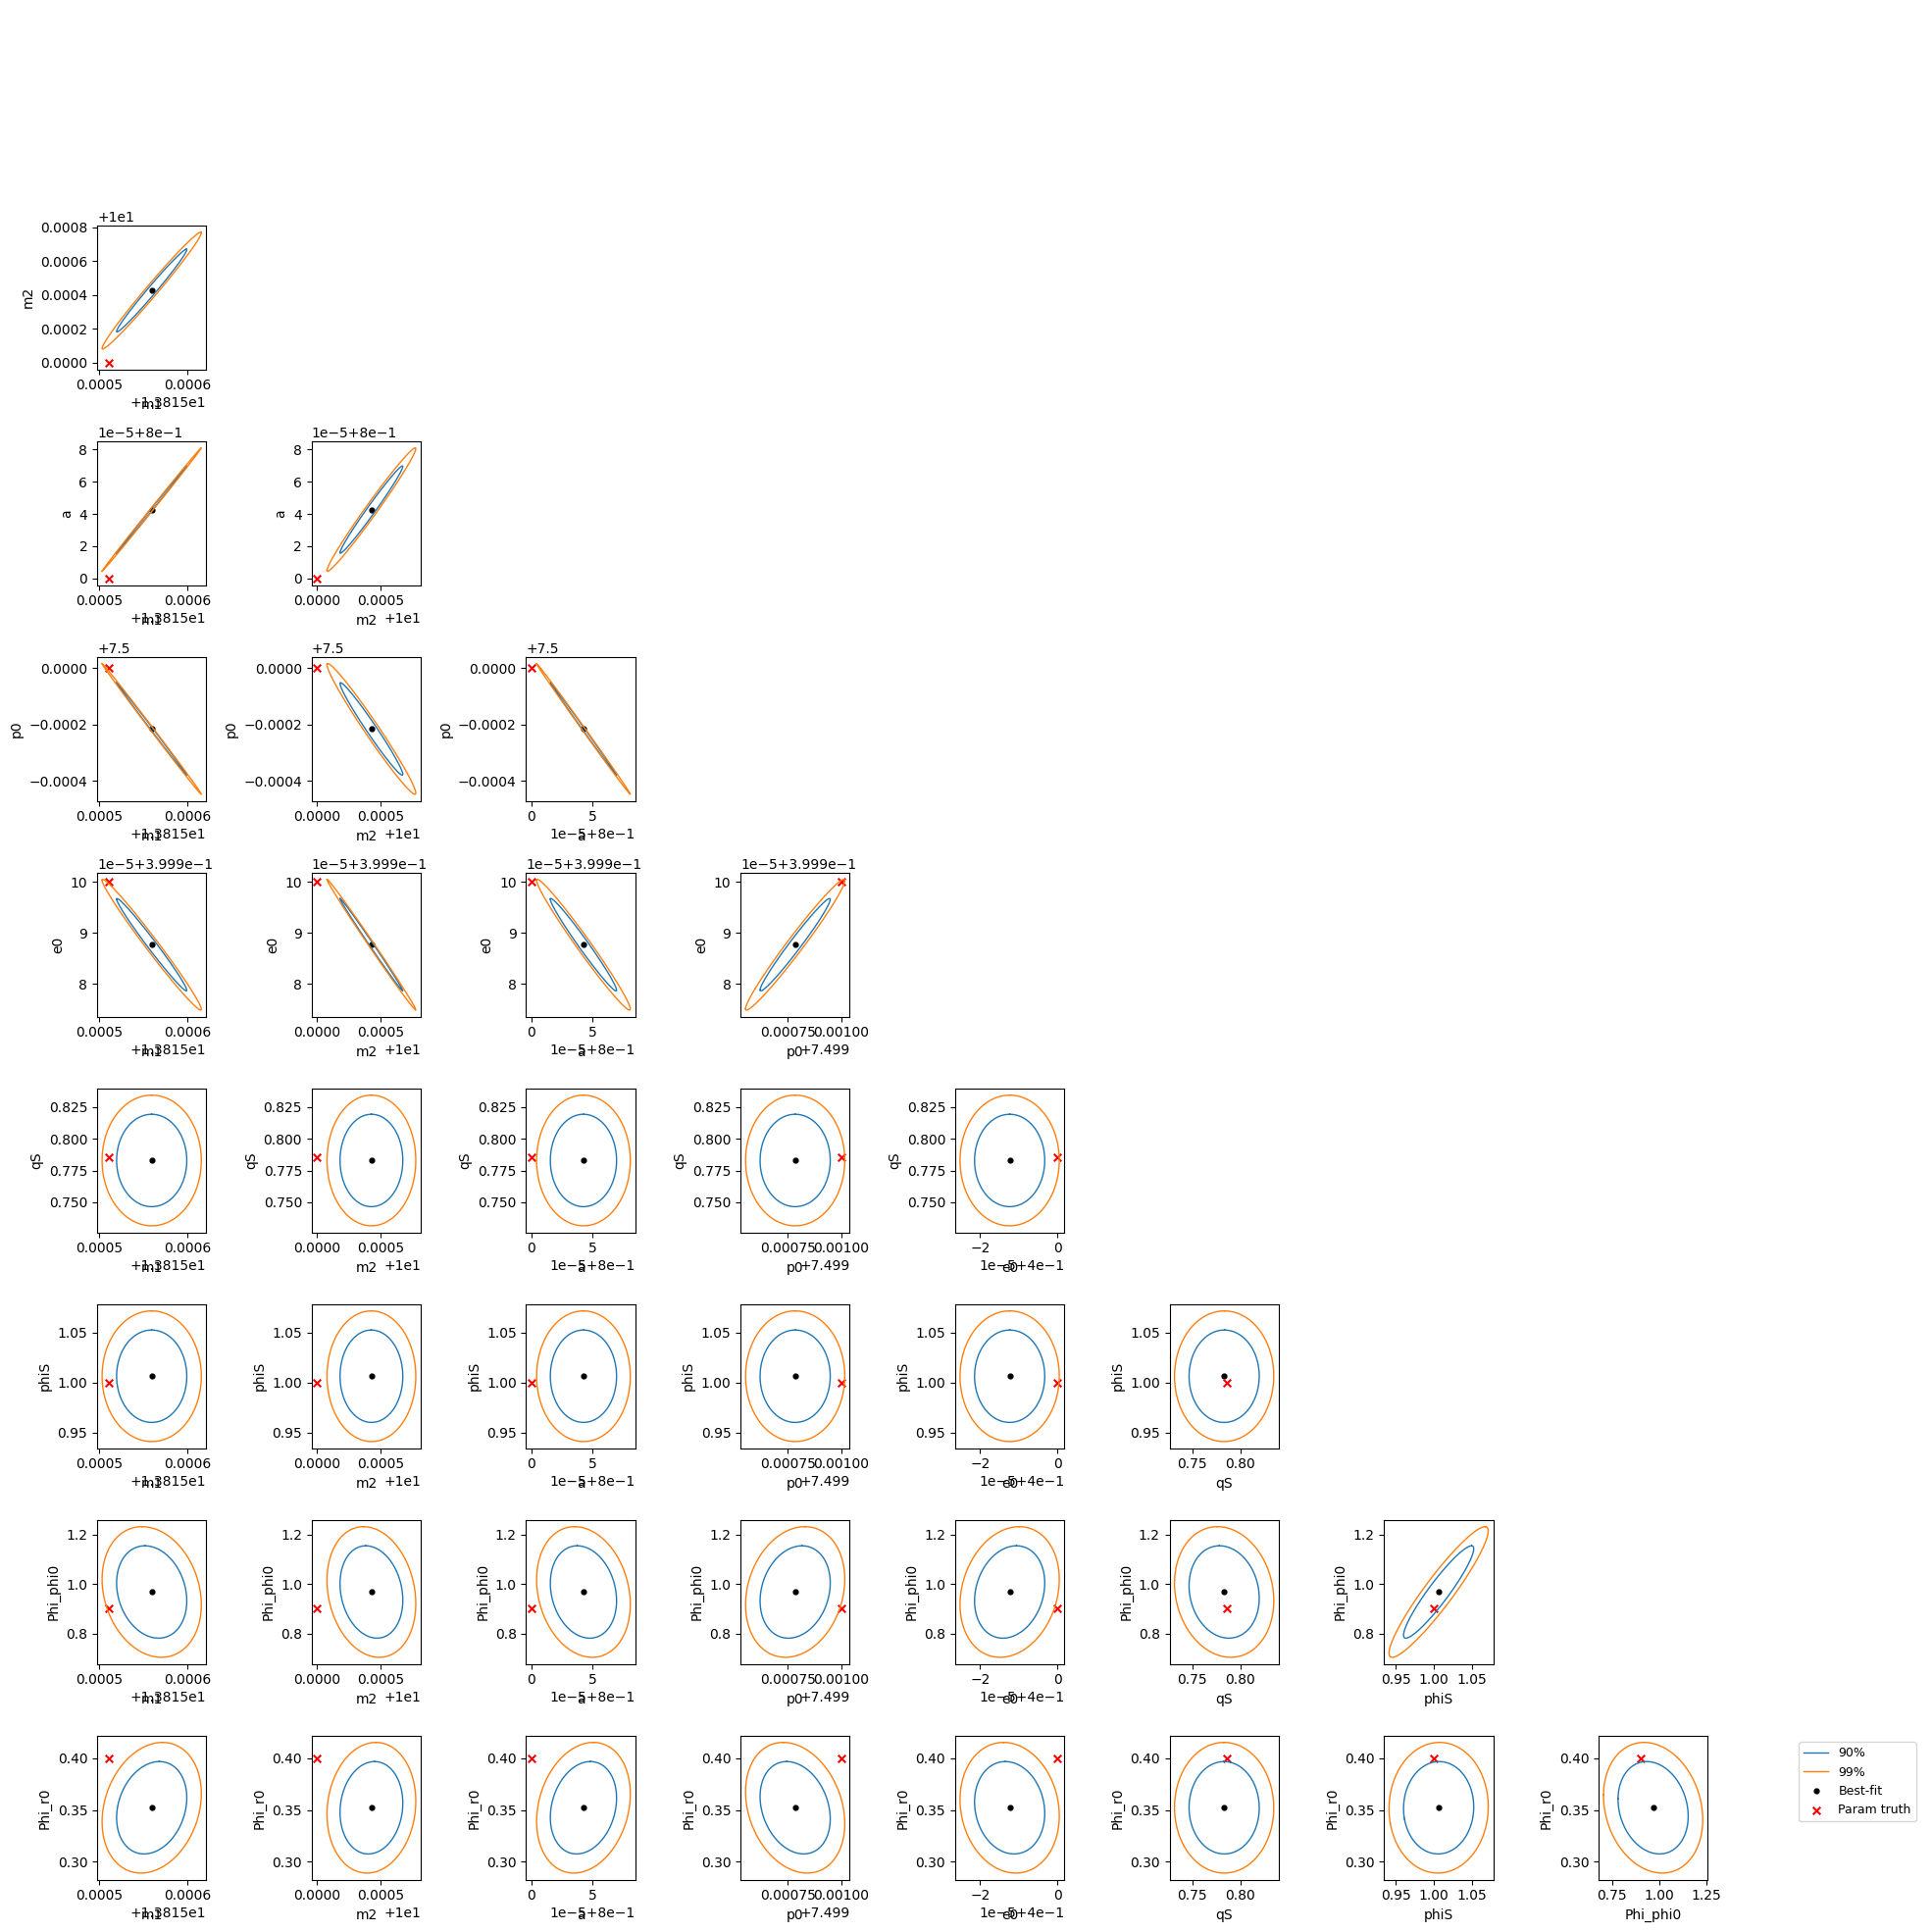

In [8]:
labels = param_names
triangle_plot(np.array(best_fit), cov, np.array(params_truth_in), labels,levels=[0.90, 0.99])

In [9]:
m1_true = 1e6
m2_true = 1e1
a_true = 0.8
e0_true = 0.4
xI0_true = 1.0
dist_true = 0.5 
qS_true = np.pi/4
phiS_true = 1.0
qK_true = 1 
phiK_true = np.pi/3

Phi_phi0_true = 0.9
Phi_theta0_true =0.5
Phi_r0_true = 0.4
p0_true=7.5

dt = 10.0
T = 1.0

chi2 = 0.9

dev_C_p=0.0
dev_C_e=0.0


evolve_1PA_true = True
evolve_primary = False
evolve_2PA = False
deviation_included=True

superkludge_wave = GenerateEMRIWaveform(SuperKludgeWaveform,\
                                    sum_kwargs=sum_kwargs,\
                                    return_list=True,
                                    mode_selector_kwargs=dict(mode_selection_threshold=1e-5),
                                    inspiral_kwargs=inspiral_kwargs,
                                    use_gpu=use_gpu)
    
add_args = [chi2,evolve_1PA_true,evolve_primary,evolve_2PA,deviation_included,dev_C_p,dev_C_e]
waveform_true = superkludge_wave(m1_true, m2_true, a_true, p0_true, e0_true, xI0_true, dist_true, qS_true, phiS_true, qK_true, phiK_true, Phi_phi0_true, Phi_theta0_true, Phi_r0_true, *add_args, dt=dt, T=T)
waveform_true= xp.asarray(waveform_true)
fisher_derivs = xp.array(Fisher[0])
fisher_exact = xp.array(Fisher[-1])



In [10]:
# baseline check - 0PA model at true parameters
evolve_1PA_approx = False
add_args = [chi2, evolve_1PA_approx, evolve_primary, evolve_2PA,deviation_included,dev_C_p,dev_C_e]

waveform_approx = superkludge_wave(m1_true, m2_true, a_true, p0_true, e0_true, xI0_true, dist_true, qS_true, phiS_true, qK_true, phiK_true, Phi_phi0_true, Phi_theta0_true, Phi_r0_true, *add_args, dt=dt, T=T)
waveform_approx= xp.asarray(waveform_approx)

In [11]:
# waveform at best fit parameters with 0PA calaculated during fisher calculation
waveform_best_fit=sef.waveform
waveform_best_fit= xp.asarray(waveform_best_fit)



# waveform analysis and p0 evolution

In [12]:
from few.utils.utility import ( 
    get_mismatch, 
    get_m2_at_t, 
    get_p_at_t, 
    )

from few.utils.geodesic import (
    get_fundamental_frequencies,
    get_separatrix,
    get_kerr_geo_constants_of_motion,
    ELQ_to_pex,
    )
SK_traj = EMRIInspiral(func=SuperKludgeFlux)
#get_p_at_t may fail with SuperKludge, especially with lower eccentricities, so we use KerrEccEq to generate p0 
add_args = [chi2, evolve_1PA_true, evolve_primary, evolve_2PA,deviation_included,dev_C_p,dev_C_e]
p_sep = get_separatrix(a_true, e0_true, xI0_true)
p0_should = get_p_at_t(traj_module=SK_traj, t_out=T, traj_args=[m1_true, m2_true, a_true, e0_true, xI0_true, *add_args])
print('should take p0 around for for true waveform: ', p0_should)
print('separatrix p: ', p_sep)

should take p0 around for for true waveform:  7.40675326711066
separatrix p:  3.3636344376256564


# P evolution is done considering true waveform (1PA)

[0.9, True, False, False, True, 0.0, 0.0]


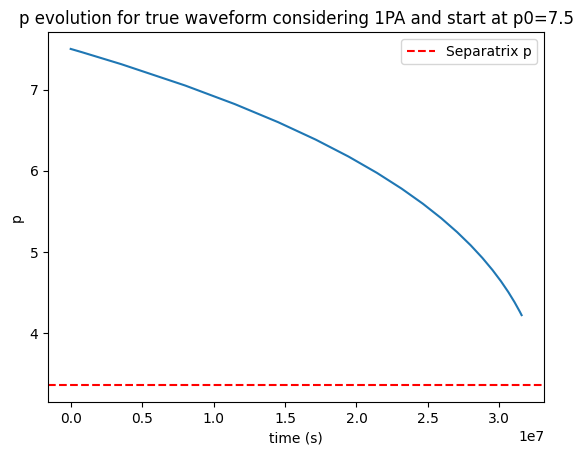

In [13]:
from scipy.interpolate import CubicSpline
add_args = [chi2, evolve_1PA_true, evolve_primary, evolve_2PA,deviation_included,dev_C_p,dev_C_e]
print(add_args) 
t_evol, p_evol, e_evol, x2_evol, pp2_evol, pt2_evol, pr2_evol, _, _ = SK_traj(m1_true, m2_true, a_true, p0_true, e0_true, xI0_true, *add_args,
                                               Phi_phi0=Phi_phi0_true, Phi_theta0=Phi_theta0_true, Phi_r0=Phi_r0_true, T=T, dt=dt)
p_evolution = CubicSpline(t_evol, p_evol)(t_evol)
plt.plot(t_evol, p_evolution)
plt.title('p evolution for true waveform considering 1PA and start at p0=7.5')
plt.xlabel('time (s)')
plt.ylabel('p')
plt.axhline(p_sep, color='red', linestyle='--', label='Separatrix p')
plt.legend()
plt.show()



# Waveform Visualization

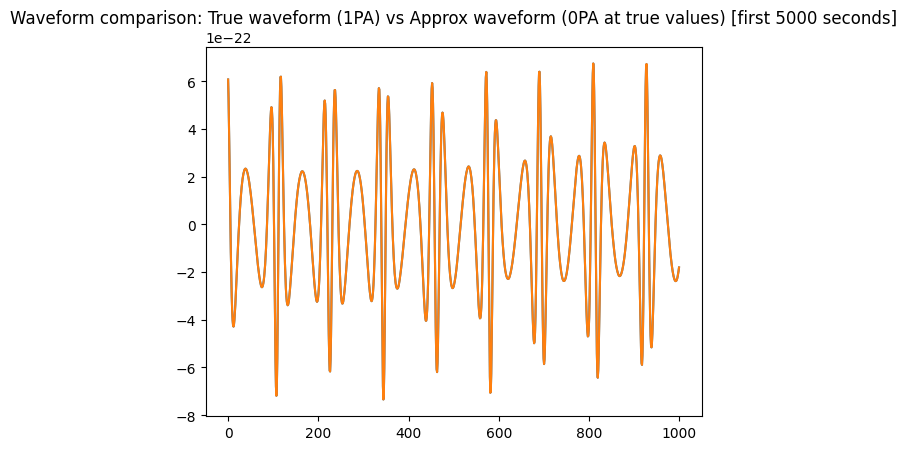

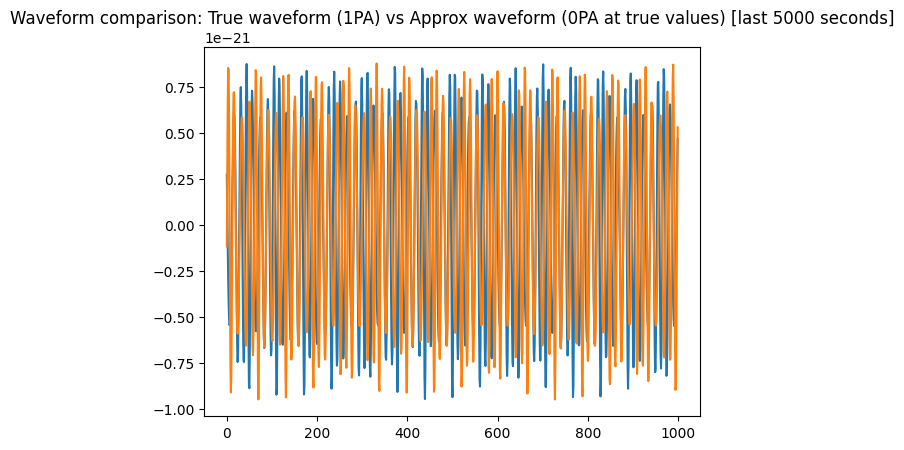

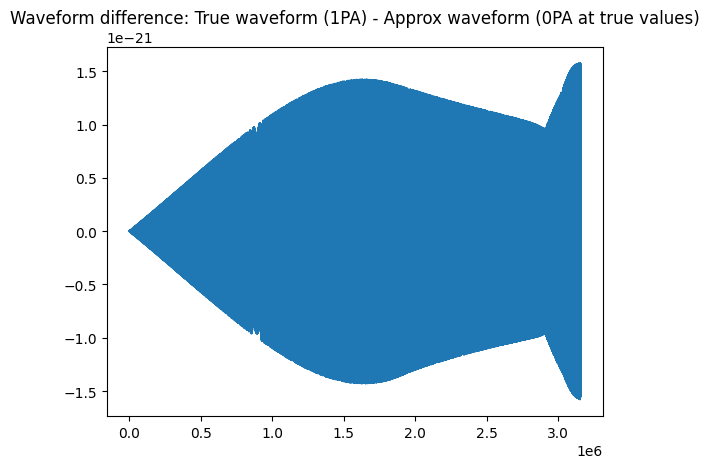

In [14]:
plt.plot(waveform_true[0][0:1000].get())
plt.plot(waveform_approx[0][0:1000].get())
plt.title('Waveform comparison: True waveform (1PA) vs Approx waveform (0PA at true values) [first 5000 seconds]')
plt.show()

plt.plot(waveform_true[0][-1000:].get())
plt.plot(waveform_approx[0][-1000:].get())
plt.title('Waveform comparison: True waveform (1PA) vs Approx waveform (0PA at true values) [last 5000 seconds]')
plt.show()
# waveform_approx
# waveform_best_fit
plt.plot((waveform_true[0]-waveform_approx[0]).get())
plt.title('Waveform difference: True waveform (1PA) - Approx waveform (0PA at true values)')
plt.show()

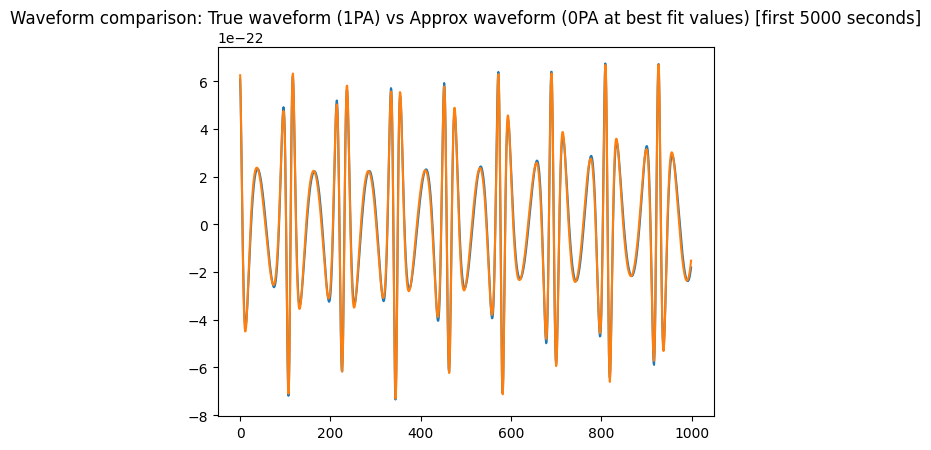

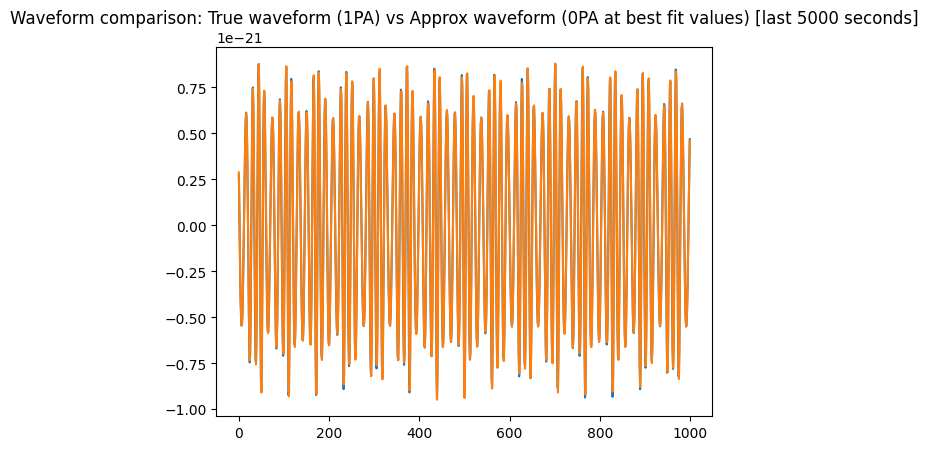

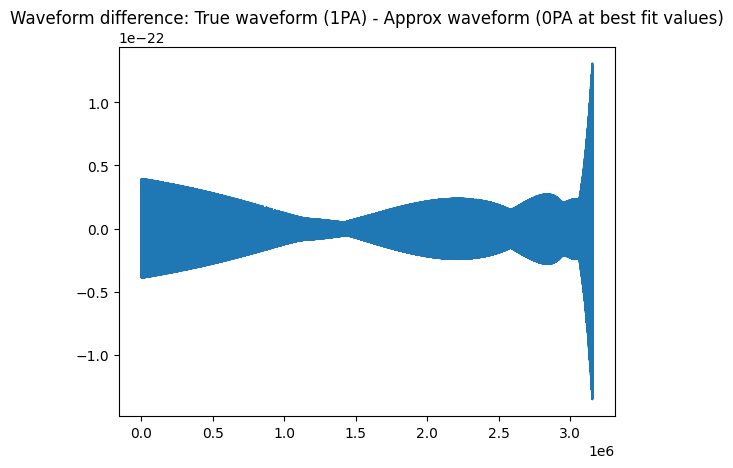

In [15]:
plt.plot(waveform_true[0][0:1000].get())
plt.plot(waveform_best_fit[0][0:1000].get())
plt.title('Waveform comparison: True waveform (1PA) vs Approx waveform (0PA at best fit values) [first 5000 seconds]')
plt.show()

plt.plot(waveform_true[0][-1000:].get())
plt.plot(waveform_best_fit[0][-1000:].get())
plt.title('Waveform comparison: True waveform (1PA) vs Approx waveform (0PA at best fit values) [last 5000 seconds]')
plt.show()
# waveform_approx
# waveform_best_fit
plt.plot((waveform_true[0]-waveform_best_fit[0]).get())
plt.title('Waveform difference: True waveform (1PA) - Approx waveform (0PA at best fit values)')
plt.show()

# Overlap and mismatch

In [19]:
PSD=generate_PSD(waveform_true,dt,use_gpu=use_gpu,
                noise_PSD=get_sensitivity,
                noise_kwargs={'sens_fn':CornishLISASens,'return_type':'PSD'},
                channels=["A","E"])
diff_inner_bf=inner_product(waveform_best_fit,waveform_true,PSD,dt,use_gpu=use_gpu)
norm_true=np.sqrt(inner_product(waveform_true,waveform_true,PSD,dt,use_gpu=use_gpu))
norm_bf=np.sqrt(inner_product(waveform_best_fit,waveform_best_fit,PSD,dt,use_gpu=use_gpu))
overlap_bf=diff_inner_bf/((norm_true)*norm_bf)
print("overlap between best fit point and true waveform:", overlap_bf)
print("mismatch between best fit point and true waveform:", 1-overlap_bf)

norm_approx=np.sqrt(inner_product(waveform_approx,waveform_approx,PSD,dt,use_gpu=use_gpu))
diff_inner_approx=inner_product(waveform_approx,waveform_true,PSD,dt,use_gpu=use_gpu)
overlap_approx=diff_inner_approx/((norm_true)*norm_approx)
print("overlap between approximate waveform and true waveform (both at true points)", overlap_approx)
print("mismatch between approximate waveform and true waveform (both at true points):", 1-overlap_approx)

overlap between best fit point and true waveform: 0.9996391030917099
mismatch between best fit point and true waveform: 0.00036089690829010923
overlap between approximate waveform and true waveform (both at true points) -0.02785825850579409
mismatch between approximate waveform and true waveform (both at true points): 1.027858258505794


In [20]:
import pandas as pd
best_fit_ = best_fit.copy()
best_fit_[0] = np.exp(best_fit[0])
truue_param=[m1_true,m2_true,a_true,p0_true,e0_true,qS_true,phiS_true,Phi_phi0_true,Phi_r0_true]
bias=np.array(truue_param)-np.array(best_fit_)
df = pd.DataFrame({'Best Fit': best_fit_, 'True Param': truue_param,'bias': bias,'bias percent': (bias/truue_param*100)}, index=param_names)
print(df)

              Best Fit      True Param       bias  bias percent
m1        1.000049e+06  1000000.000000 -49.013237     -0.004901
m2        1.000043e+01       10.000000  -0.000426     -0.004257
a         8.000428e-01        0.800000  -0.000043     -0.005344
p0        7.499784e+00        7.500000   0.000216      0.002877
e0        3.999877e-01        0.400000   0.000012      0.003080
qS        7.829562e-01        0.785398   0.002442      0.310924
phiS      1.006141e+00        1.000000  -0.006141     -0.614064
Phi_phi0  9.678475e-01        0.900000  -0.067847     -7.538606
Phi_r0    3.521521e-01        0.400000   0.047848     11.961983


In [23]:
evolve_1PA_approx=False
chi=0.9
#ppoints =  [13.81555957,10.00042571,0.80004275,7.49978425,0.39998768,0.78295617,1.00614064,0.96784745,0.35215207]
ppoints = [13.81550703,10.00009264,0.80000708,7.49999825,0.40000004,0.77786627,0.9996952,0.9775506,0.36292162] 
add_args = [chi2, evolve_1PA_approx, evolve_primary, evolve_2PA,deviation_included,0,0]
waveform_approx_check = superkludge_wave(np.exp(ppoints[0]), ppoints[1], ppoints[2], ppoints[3], ppoints[4], xI0, dist, 
                                         ppoints[5], ppoints[6], qK, phiK, ppoints[7], Phi_theta0, ppoints[8], *add_args, dt=dt, T=T)

norm_approx=np.sqrt(inner_product(waveform_approx_check,waveform_approx_check,PSD,dt,use_gpu=use_gpu))
diff_inner_approx=inner_product(waveform_approx_check,waveform_true,PSD,dt,use_gpu=use_gpu)
overlap_approx=diff_inner_approx/((norm_true)*norm_approx)
print("overlap between approximate waveform and true waveform (both at true points)", overlap_approx)
print("mismatch between approximate waveform and true waveform (both at true points):", 1-overlap_approx)

overlap between approximate waveform and true waveform (both at true points) 0.9991459641857284
mismatch between approximate waveform and true waveform (both at true points): 0.0008540358142715698
